# Facial Skin Disease Detection — Complete Pipeline
### All 7 models: Custom CNN, VGG16, ResNet50, EfficientNetB0, MobileNetV2, DenseNet121, Xception
**Run cells top to bottom. Results auto-save to Google Drive.**

##  Install packages & check GPU

In [2]:
# ── Install & GPU Check ─────────────────────────────────────────
!pip install -q kagglehub tensorflow keras scikit-learn seaborn opencv-python tqdm

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(" TensorFlow:", tf.__version__)
print(" GPUs available:", gpus if gpus else "  No GPU — go to Runtime > Change runtime type > T4 GPU")

 TensorFlow: 2.20.0
 GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print(" Drive mounted")

Mounted at /content/drive
 Drive mounted


##  Download DermNet dataset & create balanced subset

In [ ]:
import kagglehub, os, shutil, random

random.seed(42)

print(" Downloading DermNet dataset (this takes a few minutes)...")
dataset_path = kagglehub.dataset_download("shubhamgoel27/dermnet")
print(" Dataset path:", dataset_path)
print(" Splits:", os.listdir(dataset_path))

# ── Create balanced 7-class subset ──────────────────────────────
SOURCE           = dataset_path
DEST             = "/content/dermnet_subset"
IMAGES_PER_CLASS = 300   # training images per class
TEST_PER_CLASS   = 60    # test images per class

SELECTED_CLASSES = [
    "Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions",
    "Eczema Photos",
    "Melanoma Skin Cancer Nevi and Moles",
    "Nail Fungus and other Nail Disease",
    "Psoriasis pictures Lichen Planus and related diseases",
    "Tinea Ringworm Candidiasis and other Fungal Infections",
    "Warts Molluscum and other Viral Infections",
]

for split in ["train", "test"]:
    for cls in SELECTED_CLASSES:
        src = os.path.join(SOURCE, split, cls)
        dst = os.path.join(DEST, split, cls)
        os.makedirs(dst, exist_ok=True)
        images = [f for f in os.listdir(src) if f.lower().endswith((".jpg",".jpeg",".png"))]
        cap = IMAGES_PER_CLASS if split == "train" else TEST_PER_CLASS
        sampled = random.sample(images, min(cap, len(images)))
        for img in sampled:
            shutil.copy(os.path.join(src, img), os.path.join(dst, img))

print("\n Subset created:")
for split in ["train", "test"]:
    print(f"\n  [{split}]")
    for cls in SELECTED_CLASSES:
        count = len(os.listdir(os.path.join(DEST, split, cls)))
        print(f"    {cls[:55]:<55} → {count} images")

# Exploratory Data Analysis (EDA)

Dataset: DermNet

A balanced 7-class subset was created from the DermNet dataset.

Dataset Statistics:
- Training Images: 2100
- Test Images: 420
- Number of Classes: 7
- Training Images per Class: 300
- Test Images per Class: 60

The following analysis visualizes class distribution and sample images from each disease category.

In [ ]:
# Class Distribution
import matplotlib.pyplot as plt
from PIL import Image
classes = SELECTED_CLASSES

train_counts = [
    len(os.listdir(os.path.join(DEST, "train", cls)))
    for cls in classes
]

plt.figure(figsize=(12,5))
plt.bar(range(len(classes)), train_counts)
plt.xticks(range(len(classes)),
           [c[:20] + "..." for c in classes],
           rotation=45,
           ha="right")
plt.title("Training Images per Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

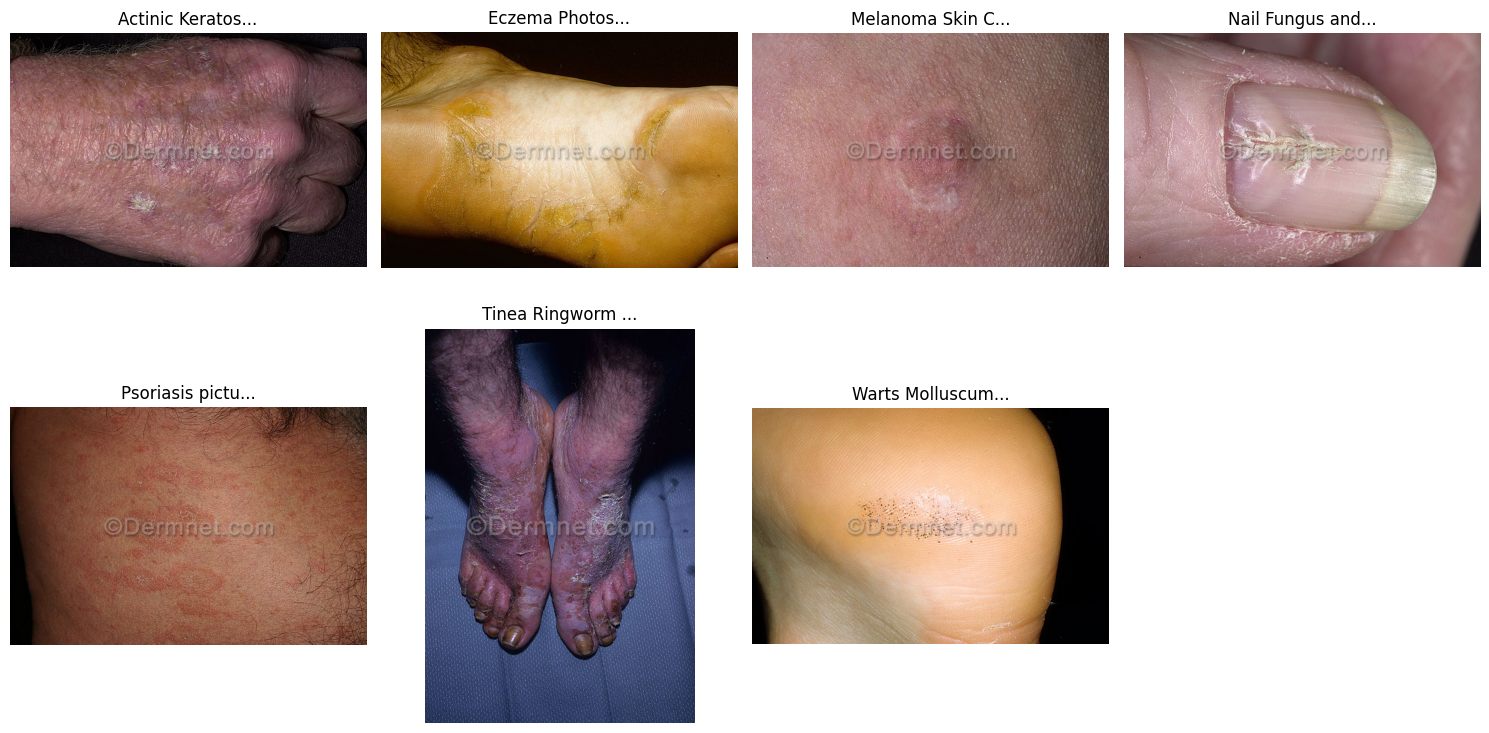

In [10]:
from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(15,8))
axes = axes.flatten()

for i, cls in enumerate(classes):
    img_name = os.listdir(os.path.join(DEST, "train", cls))[0]
    img_path = os.path.join(DEST, "train", cls, img_name)

    img = Image.open(img_path)

    axes[i].imshow(img)
    axes[i].set_title(cls[:15] + "...")
    axes[i].axis("off")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

##  Config & shared utilities (run once)

In [ ]:
import numpy as np
import matplotlib
matplotlib.use('Agg')  # non-interactive backend for Colab
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ───────────────────────────────────────────────────────
TRAIN_DIR   = "/content/dermnet_subset/train"
TEST_DIR    = "/content/dermnet_subset/test"
IMAGES_DIR  = "/content/Images"
MODELS_DIR  = "/content/saved_models"

os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

IMG_SIZE    = (224, 224)
IMG_SHAPE   = (224, 224, 3)
BATCH_SIZE  = 32
EPOCHS      = 15       # ← change to 20-30 for better accuracy
LR          = 1e-4
FINE_LR     = 1e-5     # fine-tuning LR (lower)
MIN_LR      = 1e-7
SEED        = 42
NUM_CLASSES = 7

CLASS_NAMES = [
    "Actinic Keratosis",
    "Eczema",
    "Melanoma",
    "Nail Fungus",
    "Psoriasis",
    "Tinea Ringworm",
    "Warts Molluscum",
]

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── DATA GENERATORS ──────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED, shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED, shuffle=False
)

print(" Config loaded")
print(f"   Training samples : {train_gen.samples}")
print(f"   Test samples     : {test_gen.samples}")
print(f"   Classes          : {list(train_gen.class_indices.keys())}")

Found 2100 images belonging to 7 classes.
Found 420 images belonging to 7 classes.
 Config loaded
   Training samples : 2100
   Test samples     : 420
   Classes          : ['Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Eczema Photos', 'Melanoma Skin Cancer Nevi and Moles', 'Nail Fungus and other Nail Disease', 'Psoriasis pictures Lichen Planus and related diseases', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Warts Molluscum and other Viral Infections']


##  Shared helper: train, evaluate, save plots

In [ ]:
def get_callbacks(model_name, monitor='val_accuracy'):
    return [
        callbacks.ModelCheckpoint(
            filepath=f"{MODELS_DIR}/{model_name}_best.keras",
            monitor=monitor, save_best_only=True, verbose=1
        ),
        callbacks.EarlyStopping(
            monitor=monitor, patience=5, restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3,
            min_lr=MIN_LR, verbose=1
        )
    ]


def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} — Training History", fontsize=14, fontweight='bold')

    axes[0].plot(history.history['accuracy'],    label='Train Acc', color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc',   color='orange')
    axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].set_xlabel('Epoch')

    axes[1].plot(history.history['loss'],    label='Train Loss', color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Val Loss',  color='orange')
    axes[1].set_title('Loss'); axes[1].legend(); axes[1].set_xlabel('Epoch')

    plt.tight_layout()
    path = f"{IMAGES_DIR}/{model_name}_history.png"
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.close()
    print(f"    History plot saved → {path}")


def plot_confusion_matrix(model, gen, model_name):
    gen.reset()
    preds = model.predict(gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = gen.classes

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"{model_name} — Confusion Matrix", fontsize=13, fontweight='bold')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    path = f"{IMAGES_DIR}/{model_name}_confusion_matrix.png"
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.close()
    print(f"    Confusion matrix saved → {path}")

    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
    with open(f"{IMAGES_DIR}/{model_name}_classification_report.txt", 'w') as f:
        f.write(report)
    print(f"\n{report}")
    return y_true, y_pred


def run_model(model, model_name, lr=LR, epochs=EPOCHS):
    print(f"\n{'='*60}")
    print(f"   Training: {model_name}")
    print(f"{'='*60}")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=test_gen,
        callbacks=get_callbacks(model_name),
        verbose=1
    )

    plot_history(history, model_name)

    loss, acc = model.evaluate(test_gen, verbose=0)
    print(f"\n   {model_name} → Test Accuracy: {acc*100:.2f}%  |  Test Loss: {loss:.4f}")

    plot_confusion_matrix(model, test_gen, model_name)

    model.save(f"{MODELS_DIR}/{model_name}_final.keras")
    print(f"   Model saved → {MODELS_DIR}/{model_name}_final.keras")

    return history, acc, loss


# Track all results
ALL_RESULTS = {}
print(" Helper functions ready")

 Helper functions ready


##  Model 1: Custom CNN

In [ ]:
def build_custom_cnn():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=IMG_SHAPE),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),
        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),
        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),
        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        # Head
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='Custom_CNN')
    return model

model_cnn = build_custom_cnn()
model_cnn.summary()
hist_cnn, acc_cnn, loss_cnn = run_model(model_cnn, "Custom_CNN")
ALL_RESULTS["Custom_CNN"] = {"accuracy": acc_cnn, "loss": loss_cnn}

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,59

 Total params: 721,319 (2.75 MB)

 Trainable params: 719,335 (2.74 MB)

 Non-trainable params: 1,984 (7.75 KB)


   Training: Custom_CNN
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.1882 - loss: 2.6527
Epoch 1: val_accuracy improved from None to 0.14286, saving model to /content/saved_models/Custom_CNN_best.keras

Epoch 1: finished saving model to /content/saved_models/Custom_CNN_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 81s 870ms/step - accuracy: 0.2095 - loss: 2.5599 - val_accuracy: 0.1429 - val_loss: 1.9561 - learning_rate: 1.0000e-04
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.2305 - loss: 2.4033
Epoch 2: val_accuracy did not improve from 0.14286
66/66 ━━━━━━━━━━━━━━━━━━━━ 36s 536ms/step - accuracy: 0.2376 - loss: 2.3705 - val_accuracy: 0.1429 - val_loss: 1.9849 - learning_rate: 1.0000e-04
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.2589 - loss: 2.2588
Epoch 3: val_accuracy did not improve from 0.14286
66/66 ━━━━━━━━━━━━━━━━━━━━ 34s 514ms/step - accuracy: 0.2643 - loss: 2.2990 - val_accuracy: 0.1429 - val_loss: 2.1331 - learning_ra

##   Model 2: VGG16

In [ ]:
from tensorflow.keras.applications import VGG16

def build_vgg16():
    base = VGG16(weights='imagenet', include_top=False, input_shape=IMG_SHAPE)
    # Freeze all except last 4 layers
    for layer in base.layers[:-4]:
        layer.trainable = False
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(base.input, out, name='VGG16')

model_vgg = build_vgg16()
hist_vgg, acc_vgg, loss_vgg = run_model(model_vgg, "VGG16", lr=1e-4)
ALL_RESULTS["VGG16"] = {"accuracy": acc_vgg, "loss": loss_vgg}

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

   Training: VGG16
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step - accuracy: 0.2281 - loss: 2.2304
Epoch 1: val_accuracy improved from None to 0.22857, saving model to /content/saved_models/VGG16_best.keras

Epoch 1: finished saving model to /content/saved_models/VGG16_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 82s 985ms/step - accuracy: 0.2652 - loss: 2.0526 - val_accuracy: 0.2286 - val_loss: 1.8686 - learning_rate: 1.0000e-04
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.3222 - loss: 1.7721
Epoch 2: val_accuracy improved from 0.22857 to 0.30714, saving model to /content/saved_models/VGG16_best.keras

Epoch 2: finished saving model to /content/saved_models/VGG16_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 45s 684ms/step - accuracy: 0.3424 - loss: 1.7731 - val_accuracy: 0.3071 - val_loss: 1.7862 - learning_rate: 1.0000e-04
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.3661 - loss: 1.7156
Epoch 3: val

##  Model 3: ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50

def build_resnet50():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=IMG_SHAPE)
    # Fine-tune last 30 layers
    for layer in base.layers[:-30]:
        layer.trainable = False
    for layer in base.layers[-30:]:
        layer.trainable = True
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(base.input, out, name='ResNet50')

model_resnet = build_resnet50()
hist_resnet, acc_resnet, loss_resnet = run_model(model_resnet, "ResNet50", lr=FINE_LR)
ALL_RESULTS["ResNet50"] = {"accuracy": acc_resnet, "loss": loss_resnet}

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

   Training: ResNet50
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.1823 - loss: 2.4728
Epoch 1: val_accuracy improved from None to 0.14286, saving model to /content/saved_models/ResNet50_best.keras

Epoch 1: finished saving model to /content/saved_models/ResNet50_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 78s 829ms/step - accuracy: 0.1919 - loss: 2.3779 - val_accuracy: 0.1429 - val_loss: 2.0826 - learning_rate: 1.0000e-05
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.2701 - loss: 2.1485
Epoch 2: val_accuracy did not improve from 0.14286
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 530ms/step - accuracy: 0.2538 - loss: 2.1819 - val_accuracy: 0.1405 - val_loss: 2.0942 - learning_rate: 1.0000e-05
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.2616 - loss: 2.1036
Epoch 3: val_accuracy improved from 0.14286 to 0.16667, saving model to /content/saved_models/ResNet50_best.keras

Epoch 3: finished savi

##  Model 4: EfficientNetB0

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

def build_efficientnet():
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=IMG_SHAPE)
    for layer in base.layers[:-30]:
        layer.trainable = False
    for layer in base.layers[-30:]:
        layer.trainable = True
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(base.input, out, name='EfficientNetB0')

model_eff = build_efficientnet()
hist_eff, acc_eff, loss_eff = run_model(model_eff, "EfficientNetB0", lr=FINE_LR)
ALL_RESULTS["EfficientNetB0"] = {"accuracy": acc_eff, "loss": loss_eff}

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

   Training: EfficientNetB0
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 815ms/step - accuracy: 0.1519 - loss: 2.8756
Epoch 1: val_accuracy improved from None to 0.14286, saving model to /content/saved_models/EfficientNetB0_best.keras

Epoch 1: finished saving model to /content/saved_models/EfficientNetB0_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.1638 - loss: 2.8362 - val_accuracy: 0.1429 - val_loss: 1.9900 - learning_rate: 1.0000e-05
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.1342 - loss: 2.8406
Epoch 2: val_accuracy did not improve from 0.14286
66/66 ━━━━━━━━━━━━━━━━━━━━ 33s 494ms/step - accuracy: 0.1414 - loss: 2.7954 - val_accuracy: 0.1405 - val_loss: 1.9960 - learning_rate: 1.0000e-05
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.1446 - loss: 2.7761
Epoch 3: val_accuracy did not improve from 0.14286
66/66 ━━━━━━━━━━━━━━━━━━━━ 32s 480ms/step - accuracy: 0.1386 - loss: 2

##  Model 5: MobileNetV2 (with fine-tuning)

In [ ]:
from tensorflow.keras.applications import MobileNetV2

def build_mobilenetv2():
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=IMG_SHAPE)
    # Fine-tune last 30 layers (as in your previous notebook)
    base.trainable = True
    for layer in base.layers[:-30]:
        layer.trainable = False
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(base.input, out, name='MobileNetV2')

model_mob = build_mobilenetv2()
hist_mob, acc_mob, loss_mob = run_model(model_mob, "MobileNetV2", lr=FINE_LR)
ALL_RESULTS["MobileNetV2"] = {"accuracy": acc_mob, "loss": loss_mob}

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

   Training: MobileNetV2
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.1446 - loss: 3.1397
Epoch 1: val_accuracy improved from None to 0.15238, saving model to /content/saved_models/MobileNetV2_best.keras

Epoch 1: finished saving model to /content/saved_models/MobileNetV2_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 88s 965ms/step - accuracy: 0.1524 - loss: 3.1115 - val_accuracy: 0.1524 - val_loss: 2.0701 - learning_rate: 1.0000e-05
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.1728 - loss: 2.9875
Epoch 2: val_accuracy improved from 0.15238 to 0.18810, saving model to /content/saved_models/MobileNetV2_best.keras

Epoch 2: finished saving model to /content/saved_models/MobileNetV2_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 32s 492ms/step - accuracy: 0.1819 - loss: 2.9166 - val_accuracy: 0.1881 - val_loss: 2.0168 - learning_rate: 1.0000e-05
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.1694

## Model 6: DenseNet121

In [ ]:
from tensorflow.keras.applications import DenseNet121

def build_densenet():
    base = DenseNet121(weights='imagenet', include_top=False, input_shape=IMG_SHAPE)
    for layer in base.layers[:-30]:
        layer.trainable = False
    for layer in base.layers[-30:]:
        layer.trainable = True
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(base.input, out, name='DenseNet121')

model_dense = build_densenet()
hist_dense, acc_dense, loss_dense = run_model(model_dense, "DenseNet121", lr=FINE_LR)
ALL_RESULTS["DenseNet121"] = {"accuracy": acc_dense, "loss": loss_dense}

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

   Training: DenseNet121
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.1753 - loss: 2.8855
Epoch 1: val_accuracy improved from None to 0.20476, saving model to /content/saved_models/DenseNet121_best.keras

Epoch 1: finished saving model to /content/saved_models/DenseNet121_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.1724 - loss: 2.8806 - val_accuracy: 0.2048 - val_loss: 1.9946 - learning_rate: 1.0000e-05
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.2069 - loss: 2.7622
Epoch 2: val_accuracy improved from 0.20476 to 0.26429, saving model to /content/saved_models/DenseNet121_best.keras

Epoch 2: finished saving model to /content/saved_models/DenseNet121_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 525ms/step - accuracy: 0.2133 - loss: 2.7043 - val_accuracy: 0.2643 - val_loss: 1.9763 - learning_rate: 1.0000e-05
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.2307

##  Model 7: Xception

In [ ]:
from tensorflow.keras.applications import Xception

def build_xception():
    base = Xception(weights='imagenet', include_top=False, input_shape=IMG_SHAPE)
    for layer in base.layers[:-30]:
        layer.trainable = False
    for layer in base.layers[-30:]:
        layer.trainable = True
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(base.input, out, name='Xception')

model_xcep = build_xception()
hist_xcep, acc_xcep, loss_xcep = run_model(model_xcep, "Xception", lr=FINE_LR)
ALL_RESULTS["Xception"] = {"accuracy": acc_xcep, "loss": loss_xcep}

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

   Training: Xception
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.1781 - loss: 2.6731
Epoch 1: val_accuracy improved from None to 0.23095, saving model to /content/saved_models/Xception_best.keras

Epoch 1: finished saving model to /content/saved_models/Xception_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.1810 - loss: 2.6416 - val_accuracy: 0.2310 - val_loss: 1.8875 - learning_rate: 1.0000e-05
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.2427 - loss: 2.4384
Epoch 2: val_accuracy improved from 0.23095 to 0.29762, saving model to /content/saved_models/Xception_best.keras

Epoch 2: finished saving model to /content/saved_models/Xception_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 580ms/step - accuracy: 0.2448 - loss: 2.3825 - val_accuracy: 0.2976 - val_loss: 1.8056 - learning_rate: 1.0000e-05
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.2780 - loss: 2.2713

##  Final comparison chart & summary table

In [ ]:
import pandas as pd

# ── Summary Table ────────────────────────────────────────────────
df = pd.DataFrame(ALL_RESULTS).T
df['accuracy_%'] = (df['accuracy'] * 100).round(2)
df = df.sort_values('accuracy', ascending=False)
df.index.name = 'Model'
print("\n" + "="*50)
print("       MODEL COMPARISON SUMMARY")
print("="*50)
print(df[['accuracy_%', 'loss']].to_string())
print("="*50)
print(f"\n Best model: {df.index[0]}  ({df['accuracy_%'].iloc[0]:.2f}%)")

df.to_csv(f"{IMAGES_DIR}/model_comparison.csv")

# ── Bar Chart ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(df)))
bars = ax.bar(df.index, df['accuracy_%'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Skin Disease Classification — Model Accuracy Comparison', fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, df['accuracy_%']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/all_models_comparison.png", dpi=150, bbox_inches='tight')
plt.close()
print(f"\n Comparison chart saved → {IMAGES_DIR}/all_models_comparison.png")

# ── Loss comparison ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df.index, df['loss'], color='salmon', edgecolor='black', linewidth=0.5)
ax.set_title('Model Loss Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Test Loss'); ax.set_xlabel('Model')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/all_models_loss.png", dpi=150, bbox_inches='tight')
plt.close()
print(f" Loss chart saved → {IMAGES_DIR}/all_models_loss.png")


       MODEL COMPARISON SUMMARY
                accuracy_%      loss
Model                               
VGG16                56.19  1.438128
Xception             47.62  1.450099
MobileNetV2          38.81  1.785070
ResNet50             38.10  1.730410
DenseNet121          35.48  2.134320
Custom_CNN           24.05  2.958207
EfficientNetB0       14.29  1.989974

 Best model: VGG16  (56.19%)

 Comparison chart saved → /content/Images/all_models_comparison.png
 Loss chart saved → /content/Images/all_models_loss.png


## CELL 14 — Save EVERYTHING to Google Drive

In [ ]:
import shutil, os

BASE = "/content/drive/MyDrive/SkinDiseaseProject"

os.makedirs(f"{BASE}/Images",        exist_ok=True)
os.makedirs(f"{BASE}/saved_models",  exist_ok=True)

# Copy all plots and reports
shutil.copytree("/content/Images",       f"{BASE}/Images",       dirs_exist_ok=True)
# Copy all trained models
shutil.copytree("/content/saved_models", f"{BASE}/saved_models", dirs_exist_ok=True)

print("\n Everything saved to Google Drive!")
print(f"   Drive location  : {BASE}")
print(f"   Plots & reports : {BASE}/Images/")
print(f"   Trained models  : {BASE}/saved_models/")
print("\n Files saved:")
for root, dirs, files in os.walk(BASE):
    for f in files:
        path = os.path.join(root, f)
        size = os.path.getsize(path) / 1024**2
        print(f"   {path.replace(BASE, '')}  ({size:.1f} MB)")


 Everything saved to Google Drive!
   Drive location  : /content/drive/MyDrive/SkinDiseaseProject
   Plots & reports : /content/drive/MyDrive/SkinDiseaseProject/Images/
   Trained models  : /content/drive/MyDrive/SkinDiseaseProject/saved_models/

 Files saved:
   /Images/all_models_comparison.png  (0.1 MB)
   /Images/DenseNet121_history.png  (0.1 MB)
   /Images/ResNet50_classification_report.txt  (0.0 MB)
   /Images/Custom_CNN_classification_report.txt  (0.0 MB)
   /Images/Custom_CNN_confusion_matrix.png  (0.1 MB)
   /Images/MobileNetV2_history.png  (0.1 MB)
   /Images/ResNet50_confusion_matrix.png  (0.1 MB)
   /Images/VGG16_history.png  (0.1 MB)
   /Images/MobileNetV2_classification_report.txt  (0.0 MB)
   /Images/Xception_history.png  (0.1 MB)
   /Images/Xception_confusion_matrix.png  (0.1 MB)
   /Images/DenseNet121_classification_report.txt  (0.0 MB)
   /Images/EfficientNetB0_confusion_matrix.png  (0.1 MB)
   /Images/Xception_classification_report.txt  (0.0 MB)
   /Images/VGG16_cla